# 02 - Baseline forecast
Baseline = *sell the same as the same week last year* (seasonal-naive). Metric = **WAPE** = total miss / total sales (lower is better). The model has to beat this.

In [1]:
import sys; sys.path.append('..')
import sqlite3, pandas as pd, matplotlib.pyplot as plt
con = sqlite3.connect('../data/stocksense.db')
rd = lambda t: pd.read_sql(f'select * from {t}', con)

In [2]:
bt = rd('backtest'); bt['week'] = pd.to_datetime(bt.week)
wape = lambda a, f: abs(a-f).sum() / a.sum()
print(f'Baseline WAPE: {wape(bt.units, bt.baseline):.1%} over {len(bt)} product-weeks (last 24 weeks)')

Baseline WAPE: 16.6% over 288 product-weeks (last 24 weeks)


## Example: one product, last-year baseline vs actual

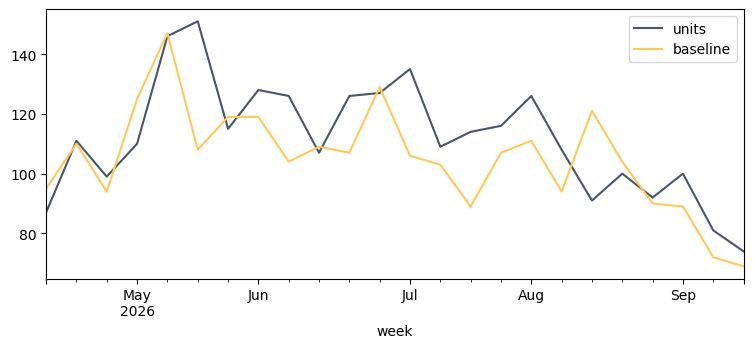

In [3]:
b = bt[bt.sku_id=='K01'].groupby('week')[['units','baseline']].mean(); b.plot(figsize=(9,3.5), color=['#4A5568','#FFC857']); plt.show()